In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [10]:
Datasalud = pd.read_csv('C:\Users\DANI\Downloads\Data set salud\heart_cleveland_upload.csv')

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (556074808.py, line 1)

In [15]:
Datasalud = pd.read_csv('C:/Users/DANI/Downloads/Data set salud/heart_cleveland_upload.csv')


In [17]:
Datasalud.head(20)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
5,64,1,0,170,227,0,2,155,0,0.6,1,0,2,0
6,63,1,0,145,233,1,2,150,0,2.3,2,0,1,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0,1
8,60,0,0,150,240,0,0,171,0,0.9,0,0,0,0
9,59,1,0,178,270,0,2,145,0,4.2,2,0,2,0


In [19]:

Datasalud.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


Text(0.5, 1.0, 'Datos por fuera de los parametros normales de colesterol sérico')

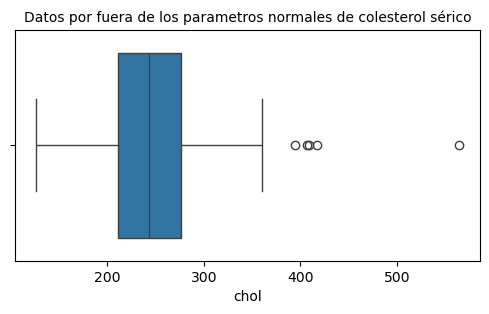

In [53]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=Datasalud['chol'])
plt.title('Datos por fuera de los parametros normales de colesterol sérico', fontsize=10)

Text(0.5, 1.0, 'Presión arterial en reposo valores Atipicos allados')

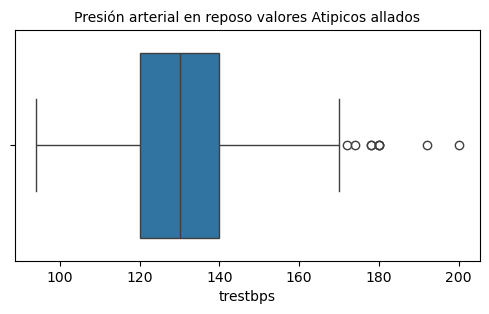

In [55]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=Datasalud['trestbps'])
plt.title('Presión arterial en reposo valores Atipicos allados', fontsize=10)

In [57]:
print("Cantidad de registros de Colesterol sérico que están por encima de 250: ", len(Datasalud[Datasalud['chol'] > 250]))
print("Cantidad de registros de Presión arterial en reposo que están por encima de 160: ", len(Datasalud[Datasalud['trestbps'] > 160]))

Cantidad de registros de Colesterol sérico que están por encima de 250:  127
Cantidad de registros de Presión arterial en reposo que están por encima de 160:  15


In [31]:
# personas con plobelas del corazon 
Datasalud ['condition'].value_counts()


condition
0    160
1    137
Name: count, dtype: int64

In [35]:
X = Datasalud.drop('condition',axis=1)
Y = Datasalud['condition']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, stratify=Y, random_state=0)

In [37]:

print (X_train)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
261   51    1   3       140   261    0        2      186      1      0.0   
121   51    0   2       140   308    0        2      142      0      1.5   
12    59    1   0       134   204    0        0      162      0      0.8   
141   44    1   2       120   226    0        0      169      0      0.0   
29    62    1   1       128   208    1        2      140      0      0.0   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
174   64    1   3       120   246    0        2       96      1      2.2   
294   35    1   3       120   198    0        0      130      1      1.6   
135   46    0   2       142   177    0        2      160      1      1.4   
252   53    1   3       123   282    0        0       95      1      2.0   
246   54    1   3       110   239    0        0      126      1      2.8   

     slope  ca  thal  
261      0   0     0  
121      0   1     0  
12       0   2    

In [39]:
print (X_test)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
129   49    1   2       118   149    0        2      126      0      0.8   
7     61    1   0       134   234    0        0      145      0      2.6   
162   67    1   3       125   254    1        0      163      0      0.2   
183   63    1   3       130   330    1        2      132      1      1.8   
264   50    1   3       144   200    0        2      126      1      0.9   
263   50    1   3       150   243    0        2      128      0      2.6   
279   44    1   3       120   169    0        0      144      1      2.8   
35    57    1   1       154   232    0        2      164      0      0.0   
280   44    1   3       112   290    0        2      153      0      0.0   
224   57    1   3       150   276    0        2      112      1      0.6   
272   46    0   3       138   243    0        2      152      1      0.0   
177   64    1   3       128   263    0        0      105      1      0.2   
111   54    

In [41]:
# Entrnando en modelo

modelo_regresion = LogisticRegression(solver = "liblinear")
modelo_regresion.fit (X_train, Y_train)

prediccion = modelo_regresion.predict(X_test)

In [43]:

X_test.head(15)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
129,49,1,2,118,149,0,2,126,0,0.8,0,3,0
7,61,1,0,134,234,0,0,145,0,2.6,1,2,0
162,67,1,3,125,254,1,0,163,0,0.2,1,2,2
183,63,1,3,130,330,1,2,132,1,1.8,0,3,2
264,50,1,3,144,200,0,2,126,1,0.9,1,0,2
263,50,1,3,150,243,0,2,128,0,2.6,1,0,2
279,44,1,3,120,169,0,0,144,1,2.8,2,0,1
35,57,1,1,154,232,0,2,164,0,0.0,0,1,0
280,44,1,3,112,290,0,2,153,0,0.0,0,1,0
224,57,1,3,150,276,0,2,112,1,0.6,1,1,1


In [45]:
print (classification_report(Y_test,prediccion))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        32
           1       0.89      0.86      0.87        28

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



Matriz de Confusión:
 [[29  3]
 [ 4 24]]


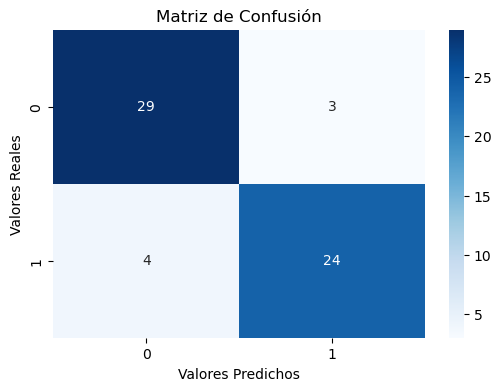

In [47]:
matriz_conf = confusion_matrix(Y_test, prediccion)

# Mostrarla como texto
print("Matriz de Confusión:\n", matriz_conf)

# Dibujarla con un mapa de calor
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Valores Predichos')
plt.ylabel('Valores Reales')
plt.show()

In [49]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, prediccion)
print(f'Accuracy: {accuracy:.4f}')


Accuracy: 0.8833


In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(Y_test, prediccion)
recall = recall_score(Y_test, prediccion)
f1 = f1_score(Y_test, prediccion)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\nReporte completo:")
print(classification_report(Y_test, prediccion))


Precision: 0.8889
Recall: 0.8571
F1 Score: 0.8727

Reporte completo:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89        32
           1       0.89      0.86      0.87        28

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60

